### Machine Learning HW 3: Boosting Decision Trees & Random Forest

Violet Park – November 2025
  
### **Part 1: Determining Splits**
Below is a sample dataset of mushrooms and it's attributes the intention is to classify them as poisonous or not.

Build a decision tree by hand show all yout calculation in either pen or notepad to classify the mushrooms and answer the questions below.

![q1](q1.png)

**1. What is the entropy of the target variable, "poisonous"?**

In [21]:
import math

P_poisonous_Y = 5/12
P_poisonous_N = 7/12

H_Y = (-P_poisonous_Y*math.log2(P_poisonous_Y)) + (-P_poisonous_N*math.log2(P_poisonous_N))
print(H_Y)

0.9798687566511528


The entropy of the target variable, "poisonous", is 0.98.

**2. What is the first attribute a decision tree trained using the entropy and the information gain method?**

In [25]:
# x1
P_size1 = 4/12
P_size2 = 2/12
P_size3 = 1/12
P_size4 = 3/12
P_size5 = 2/12

H_size1 = (-2/4)*math.log2(2/4) + (-2/4)*math.log2(2/4)
H_size2 = 0 + (-2/2)*math.log2(2/2)
H_size3 = 0 + (-1/1)*math.log2(1/1)
H_size4 = (-2/3)*math.log2(2/3) + (-1/3)*math.log2(1/3)
H_size5 = (-1/2)*math.log2(1/2) + (-1/2)*math.log2(1/2)

H_Ygivensize = P_size1*H_size1 + P_size2*H_size2 + P_size3*H_size3 + P_size4*H_size4 + P_size5*H_size5
print(f"H(Y|size) = {H_Ygivensize}")

info_gain_size = H_Y - H_Ygivensize
print(f"size IG(Y|X) = {info_gain_size}")

# x2
P_spotsY = 7/12
P_spotsN = 5/12

H_spotsN = 0 + (-1)*math.log2(1)
H_spotsY = (-5/7)*math.log2(5/7) + (-2/7)*math.log2(2/7)

H_Ygivenspots = P_spotsY*H_spotsY + P_spotsN*H_spotsN
print(f"H(Y|spots) = {H_Ygivenspots}")

info_gain_spots = H_Y - H_Ygivenspots
print(f"spots IG(Y|X) = {info_gain_spots}")

# x3
P_white = 6/12
P_brown = 6/12

H_white = (-2/6)*math.log2(2/6) + (-4/6)*math.log2(4/6)
H_brown = (-3/6)*math.log2(3/6) + (-3/6)*math.log2(3/6)

H_Ygivencolor = P_white*H_white + P_brown*H_brown
print(f"H(Y|color) = {H_Ygivencolor}")

info_gain_color = H_Y - H_Ygivencolor
print(f"color IG(Y|X) = {info_gain_color}")

H(Y|size) = 0.7295739585136224
size IG(Y|X) = 0.2502947981375304
H(Y|spots) = 0.5034869983305348
spots IG(Y|X) = 0.476381758320618
H(Y|color) = 0.9591479170272448
color IG(Y|X) = 0.020720839623908027


Given that decision trees trained using this method use the attribute with the highest information gain at each split, the first attribute would be whether or not the mushroom has spots (x<sub>2</sub>), as calculated above. The spots attribute also reduces the most uncertainty about Y, as it has the lowest conditional entropy as well.

**3. What is the information gain of this attribute?**

The information gain for the spots attribute, as calculated in the above code chunk, is 0.476.

**4. Draw the full decision tree learned from this data set.**

![part1_tree.png](part1_tree.png)

Spots is used as the first split point, given its highest information gain and lowest entropy. Given the data set, all observations that do not have spots are not poisonous, so the spots = No leaf is pure. Size is the next split point in the tree at the spots = Yes branch, with the next highest information gain. Observations here that are size 2 or 3 are not poisonous, while observations that are size 1, 4, or 5 are poisonous. At this point in the tree, all observations have been classified and all branches/leaves are pure. Therefore, splitting further by color does not change anything, so it has not been included in the tree for this data set.

### **Part 2: Decision Tree**
Download the Breast cancer dataset from https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+%28Diagnostic%29

In [35]:
# using the python import method suggested by the website

!pip install ucimlrepo

In [41]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17) 
  
# data (as pandas dataframes) 
X = breast_cancer_wisconsin_diagnostic.data.features 
y = breast_cancer_wisconsin_diagnostic.data.targets

y = y["Diagnosis"]
  
# metadata 
print(breast_cancer_wisconsin_diagnostic.metadata) 
  
# variable information 
print(breast_cancer_wisconsin_diagnostic.variables)

{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

**1. Divide the data into train (80%) and test (20%).**

In [42]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# encoding the classes so that the models can handle all of the data
le = LabelEncoder()
diagnosis_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.2,
                                                    random_state = 42,
                                                    stratify = y)
# also using stratify = y so that the class outcomes are relatively even for both the training and test sets, preventing unbalanced data

**2. Using the appropriate package to train the Decision Tree Classifier using all the features of the data and test your model on the test data.**

In [57]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

clf_train = DecisionTreeClassifier().fit(X_train, y_train)

test_pr = clf_train.predict(X_test)
print(f"Model Accuracy on Test Data: {accuracy_score(y_test, test_pr)}")
print(f"ROC AUC: {roc_auc_score(y_test, clf_train.predict_proba(X_test)[:, 1])}")

Model Accuracy on Test Data: 0.9210526315789473
ROC AUC: 0.9176587301587301


The model has an accuracy score of 0.921 (92.1%) and a ROC AUC of 0.918 (91.8%) when testing it on the test data, which is good.

**3. Run the model for trees of depth 1, 2, 3, 4, 5, and 6 and for the Gini Impurity and Entropy impurity measures.**

In [63]:
results = []

for criterion in ["entropy", "gini"]:
    for depth in range(1, 7):
        clf = DecisionTreeClassifier(criterion = criterion,
                                     max_depth = depth,
                                     random_state = 42)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        results.append({
        "criterion": criterion,
        "max_depth": depth,
        "accuracy": accuracy,
        "ROC AUC": roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1]),
        "precision": precision_score(y_test, y_pred, pos_label = "M"),
        "recall": recall_score(y_test, y_pred, pos_label = "M")})

results_df = pd.DataFrame(results)
print(results_df)

   criterion  max_depth  accuracy   ROC AUC  precision    recall
0    entropy          1  0.885965  0.845238   1.000000  0.690476
1    entropy          2  0.885965  0.970899   1.000000  0.690476
2    entropy          3  0.938596  0.988261   0.926829  0.904762
3    entropy          4  0.929825  0.943122   1.000000  0.809524
4    entropy          5  0.956140  0.944775   0.974359  0.904762
5    entropy          6  0.929825  0.944940   0.972222  0.833333
6       gini          1  0.877193  0.843254   0.937500  0.714286
7       gini          2  0.921053  0.918981   0.971429  0.809524
8       gini          3  0.903509  0.875000   0.942857  0.785714
9       gini          4  0.912281  0.876984   0.944444  0.809524
10      gini          5  0.921053  0.944775   0.945946  0.833333
11      gini          6  0.921053  0.894841   0.923077  0.857143


**4. Determine the best model and visualize it.**

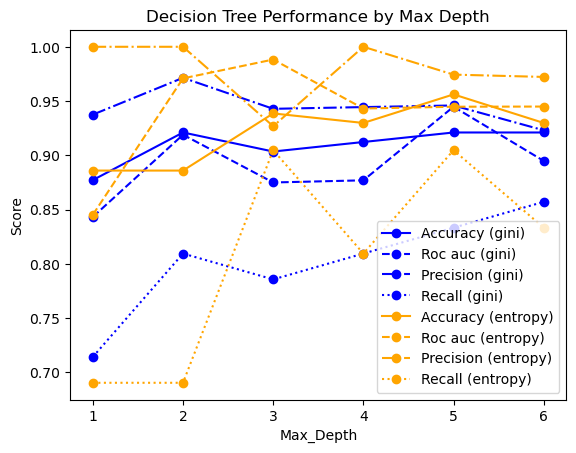

In [67]:
import matplotlib.pyplot as plt

colors = {"gini": "blue", "entropy": "orange"}
lines = {"accuracy": "-", "ROC AUC": "--", "precision": "-.", "recall": ":"}

metrics = ["accuracy", "ROC AUC", "precision", "recall"]

for criterion in ["gini", "entropy"]:
    subset = results_df[results_df["criterion"] == criterion]
    for metric in metrics:
        plt.plot(subset["max_depth"], subset[metric],
                 color = colors[criterion],
                 linestyle = lines[metric],
                 marker = "o",
                 label = f"{metric.capitalize()} ({criterion})")

plt.xlabel("Max_Depth")
plt.ylabel("Score")
plt.title("Decision Tree Performance by Max Depth")
plt.xticks(range(1,7))
plt.legend()
plt.show()

As a part of the previous question, I included some metrics to be calculated for each of the possible models. These included accuracy, ROC AUC, precision, and recall. I've created a diagram displaying each of these metrics for all possible model types (entropy vs gini for max depths 1-6). When accounting for all metrics in the context of this classification problem, it seems as though the model using **entropy and a max depth of 5** is the best. When looking at the plot, the metric points for the model using entropy at max depth 5 displays the best clustering at the highest values for these metrics, out of all other model possibilities. This model has a 95.6% accuracy in correctly classifying the test set observations. It has a 94.5% ROC AUC, meaning that the model is very good at assigning higher predicted probabilities to malignant cases. It has a 97.4% chance of predicting malignant tumors that are actually malignant and a 90.5% chance of successfully detecting malignant tumors.

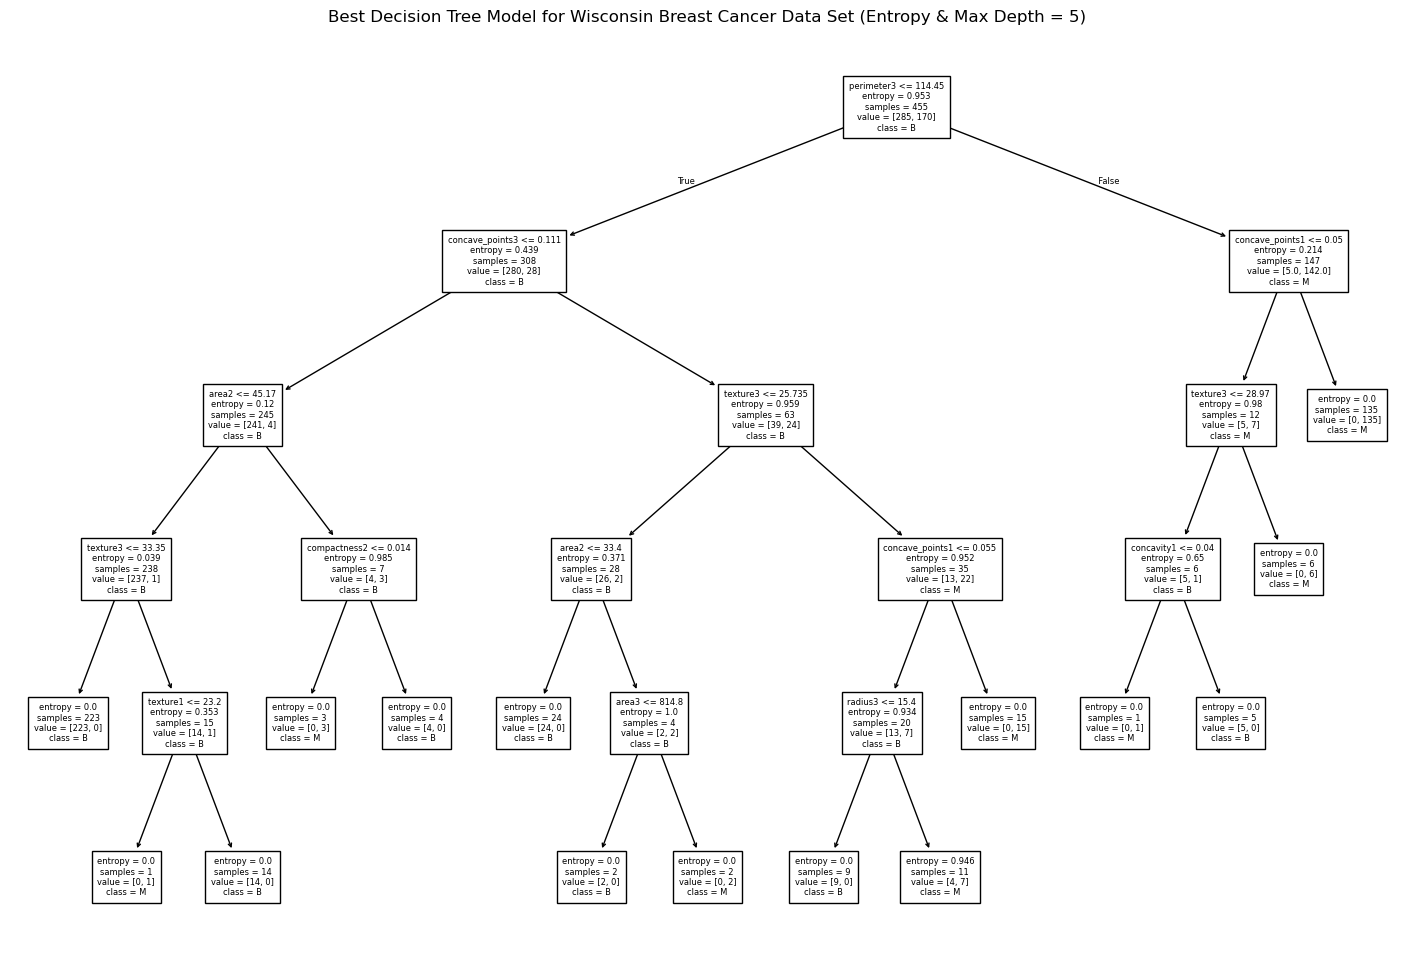

In [76]:
from sklearn import tree

clf_best = DecisionTreeClassifier(criterion = "entropy",
                                     max_depth = 5,
                                     random_state = 42)
clf_best.fit(X_train, y_train)

plt.figure(figsize=(18, 12))
plot = tree.plot_tree(clf_best,
                      feature_names = X.columns,
                      class_names = le.classes_,
                      fontsize = 6)
plt.title("Best Decision Tree Model for Wisconsin Breast Cancer Data Set (Entropy & Max Depth = 5)")
plt.show()

Here, I have visualized the actual decision tree using entropy and a max depth of 5.

### **Part 3: Random Forest**
Using the same dataset as above

**1. Use the same training and test set as above.**

In [79]:
# no code needed, as training and test data sets are saved from above

**2. Use the RandomForest classifier (https://scikit-learn.org/stable/modules/generated/
sklearn.ensemble.RandomForestClassifier.html) to create a model.**

In [82]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(random_state = 42)
rfc.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

**3. Compare the parameters that are provided for the Random Forest classifier and Decision
Tree classifier. How many are the same and how many are different?**

Parameters that are the same across these two classifiers include criterion, max_depth, min_samples_split, min_samples_leaf, min_weight_fraction_leaf, max_features, max_leaf_nodes, min_impurity_decrease, class_weight, and random_state. Parameters that are different include n_estimators, bootstrap, oob_score, n_jobs, splitter, and verbose. Many parameters are the same and a few are different.

**4. Use the Grid Search method to run the model for trees of depth 1, 2, 3, 4, 5, and 6 and for the
Gini Impurity and Entropy impurity measures. Also set the parameter so it will use the "out
of-bag" samples for calculating accuracy.**

In [101]:
from sklearn.model_selection import GridSearchCV

parameters_rf = {"max_depth": [1,2,3,4,5,6],
                 "criterion": ["entropy", "gini"],
                 "oob_score": [True]}

rf = RandomForestClassifier(random_state = 42)

clf_rf = GridSearchCV(estimator = rf, param_grid = parameters_rf,
                      scoring = "accuracy")

clf_rf.fit(X_train, y_train)

best_rf = clf_rf.best_estimator_
print(f"Best hyperparameters: {clf_rf.best_params_}")

Best hyperparameters: {'criterion': 'gini', 'max_depth': 6, 'oob_score': True}


**5. Test the accuracy of RandomForest using the Test set.**

In [99]:
y_pred_rf = best_rf.predict(X_test)
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]

print(f"OOB Accuracy of Best RandomForest Model on Test Set: {best_rf.oob_score_}")
print(f"ROC AUC of Best RandomForest Model on Test Set: {roc_auc_score(y_test, y_proba_rf)}")

OOB Accuracy of Best RandomForest Model on Test Set: 0.9560439560439561
ROC AUC of Best RandomForest Model on Test Set: 0.9953703703703702


**6. Compare the performance of Decision Tree with Boost and Random Forest.**

In [100]:
from sklearn.ensemble import AdaBoostClassifier

boost = AdaBoostClassifier(estimator = DecisionTreeClassifier(max_depth = 5), random_state = 42)

boost.fit(X_train, y_train)
y_pred_boost = boost.predict(X_test)
y_prob_boost = boost.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_boost)}")
print(f"ROC AUC: {roc_auc_score(y_test, y_prob_boost)}")

Accuracy: 0.9649122807017544
ROC AUC: 0.9923941798941798


Now that I have run the best Decision Tree model with Boost, it seems like the Decision Tree performs slightly better than the best RandomForest Model. The Decision Tree gives an accuracy of 96.5% and a ROC AUC of 99.2%, while the RandomForest model gives an OOB accuracy of 95.6% and a ROC AUC of 99.5%. The best Decision Tree model uses the entropy criterion and a max depth of 5. The best RandomForest model uses the gini criterion and a max depth of 6.

### **Part 4: XGBoost**
This is a method that we have not discussed in class but has gained popularity. Explain how XGBoost works and compare it to Adaboost and Gradientbook. Use diagrams to explain if its helpful.

XGBoost is a more extreme version of gradient boosting, which additionally uses a regularization technique (like L1 and L2) within the algorithm to prevent overfitting. Because of this, it performs better than traditional gradient boosting. XGBoost also has a built-in ability to handle missing values without the need for imputation, and it can also do multi-class classification, unlike GradientBoosting and AdaBoost. Traditional GradientBoosting is based on stagewise addition of weaker learning algorithms into a stronger final learning algorithm. The final model is built upon these previous learners in a way that corrects the errors of them. AdaBoost also uses similar stagewise addition, but its alpha parameter is instead indirectly proportional to the error of the weak learning algorithm. Instead of directly minimizing the gradient of a loss function, AdaBoost focuses on assigning weights to misclassified data points. All three methods are ensemble methods that use decision trees as base models and can be used for both regression and classification problems.

### **Bonus: Information Gain**
Information gain is calculated using Shannon Entropy, the generic description of which is:

![info_gain.png](info_gain.png)

Where H(X) is the entropy of the system X and P(xi) represents the probability of an event occurring. Since log of a value less than 1 (and probabilities are between 0 and 1) is negative, the negative multiplier in the front just converts the negative sum into a positive value.

For a binary decision tree, we have been using log2 for our
calculations. This naturally presents the information of the binary tree as “bits” (only 2 value outcomes). This formulation has been extended to generate DNA motif logos with the equation:

![info_gain2.png](info_gain2.png)

Where P(b,i) is the frequency of a base in a given position i for a string of DNA, and B is the possible values of bases in the alphabet.

**5.1) What is the value of log2(B)?**

Since there are 4 possible bases for DNA, the value of log2(B) is log2(4) = 2 bits.

**5.2) Why does that addition have to be there?**

Typically, to find information gain, you subtract the remaining uncertainty after knowing X from the total uncertainty in Y. Here, the addition is there to maintain this subtraction of entropy, since it will inherently be negative in the equation. This makes sure that the uncertainty after knowing the base is subtracted from the total uncertainty or possible information content in a string of DNA (2 bits).

**5.3) Can you think of an intuitive log base that would allow you to remove the log2(B) addition and just use our traditional negative sign to calculate the entropy of a DNA string?**

Using a log base equivalent to B, or 4 in the case of DNA, would allow you to remove the log2(B) addition. This would give a value of 1, and you wouldn't have to explicitly subtract the entropy anymore becuase it is normalized between 0 and 1. Therefore, the information content could be calculated by simply subtracting entropy from 1.

**5.4) Extending that logic, what would be an intuitive log base to generate a logo for a string of amino acids?**

Example sequence logo from wikipedia:

![info_gain3.png](info_gain3.png)

An intuitive log base for generating a logo for a string of amino acids would be 20, since there are 20 amino acids. This would again give a maximum entropy per position equal to 1 and allow for a simple subtraction of normalized entropy from 1. 